In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import option_price, option_price_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import BSM_pricing
from greeks import delta, theta, gamma, vega, rho

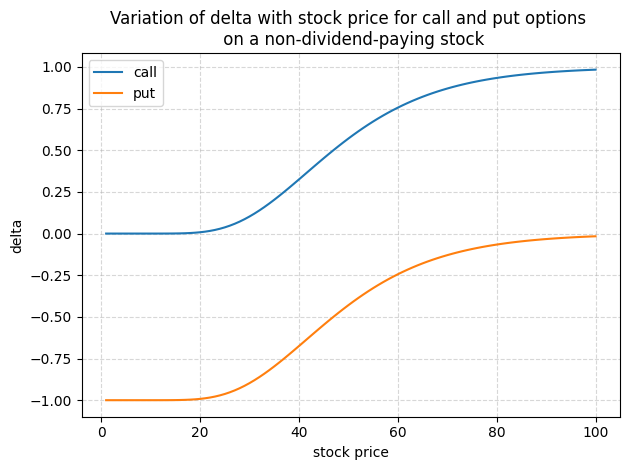

In [16]:
stocks = np.linspace(1,100,100)
k, r, sigma, T = 50, 0, 0.25, 2

deltas_call = delta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
deltas_put = delta(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

plt.plot(stocks, deltas_call, label='call')
plt.plot(stocks, deltas_put, label='put')
plt.ylabel('delta')
plt.xlabel('stock price')
plt.title('Variation of delta with stock price for call and put options \n on a non-dividend-paying stock')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

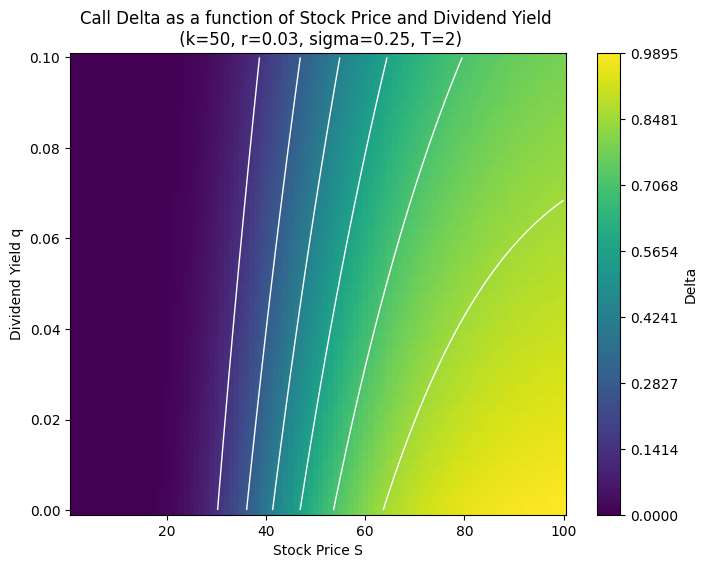

In [15]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

delta_map = delta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)

levels = np.linspace(delta_map.min(), delta_map.max(), 8)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(S, Q, delta_map, shading='auto')
plt.contour(S, Q, delta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Delta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Call Delta as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2)')
plt.show()

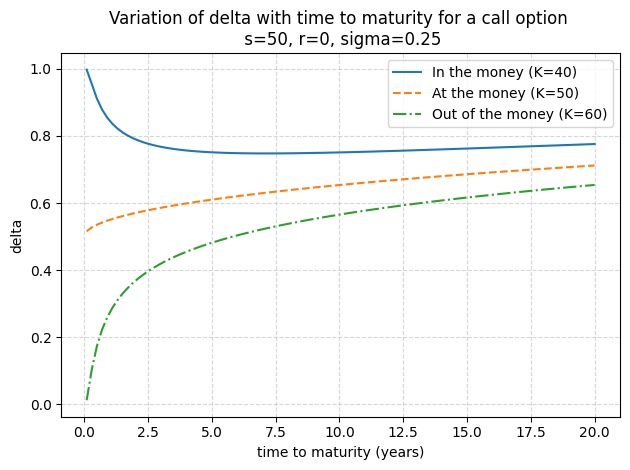

In [17]:
maturities = np.linspace(0.1,20,100)


for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    deltas_call = delta(option_type='call', s=50, k=k, r=0, sigma=0.25, T=maturities)
    plt.plot(maturities, deltas_call, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('delta')
plt.xlabel('time to maturity (years)')
plt.title('Variation of delta with time to maturity for a call option \n s=50, r=0, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

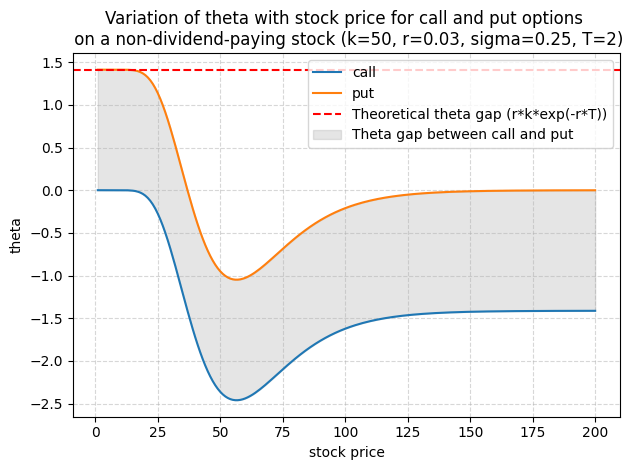

In [18]:
stocks = np.linspace(1,200,200)
k, r, sigma, T = 50, 0.03, 0.25, 2

thetas_call = theta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
thetas_put = theta(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

theta_gap = r*k*np.exp(-r*T)

plt.plot(stocks, thetas_call, label='call')
plt.plot(stocks, thetas_put, label='put')
plt.axhline(y=theta_gap, color='r', linestyle='--', label='Theoretical theta gap (r*k*exp(-r*T))')
plt.fill_between(stocks, thetas_call, thetas_put, color='grey', alpha=0.2, label='Theta gap between call and put')
plt.ylabel('theta')
plt.xlabel('stock price')
plt.title('Variation of theta with stock price for call and put options \n on a non-dividend-paying stock (k=50, r=0.03, sigma=0.25, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

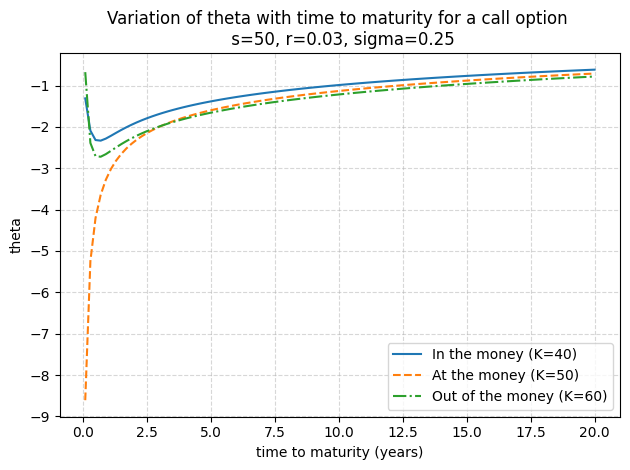

In [19]:
maturities = np.linspace(0.1,20,100)

for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    thetas_call = theta(option_type='call', s=50, k=k, r=0.03, sigma=0.25, T=maturities)
    plt.plot(maturities, thetas_call, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('theta')
plt.xlabel('time to maturity (years)')
plt.title('Variation of theta with time to maturity for a call option \n s=50, r=0.03, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

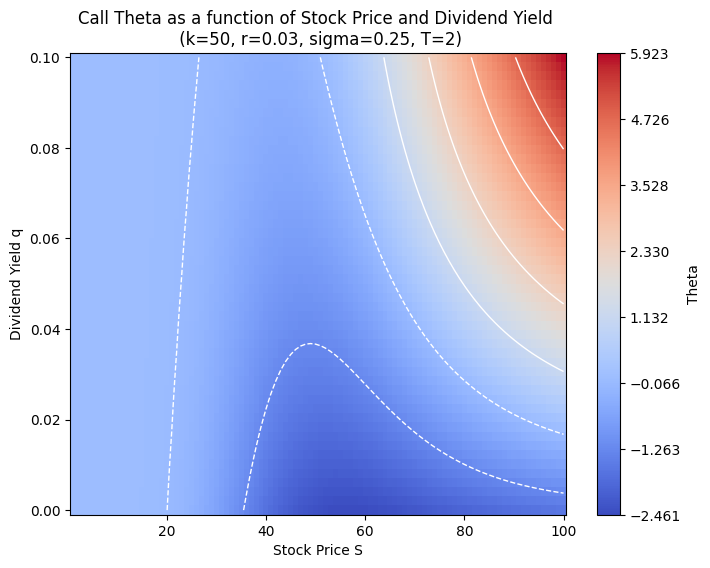

In [20]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

theta_map = theta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(theta_map.min(), theta_map.max(), 8)

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(S, Q, theta_map, shading='auto', cmap='coolwarm')
plt.contour(S, Q, theta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Theta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Call Theta as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2)')
plt.show()

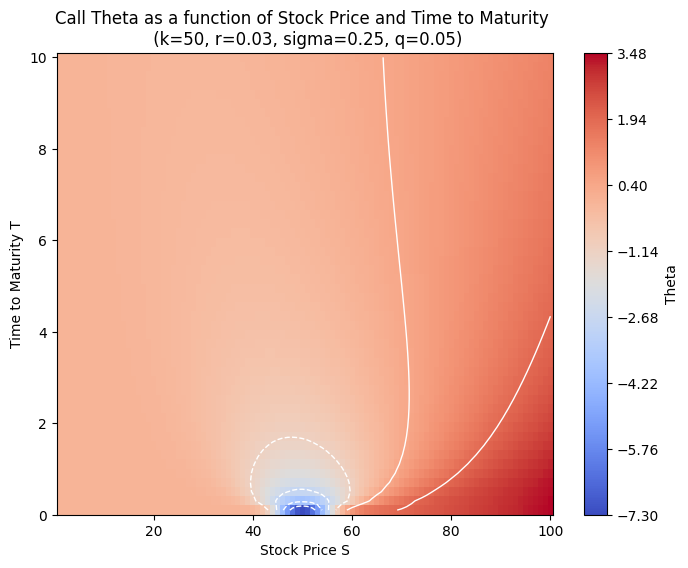

In [21]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

theta_map = theta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)

levels = np.linspace(theta_map.min(), theta_map.max(), 8)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(S, M, theta_map, shading='auto', cmap='coolwarm')
plt.contour(S, M, theta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Theta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Call Theta as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.show()

/var/folders/d_/6y86tpf532z078fl9rsr03b40000gn/T/ipykernel_23358/1606770199.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


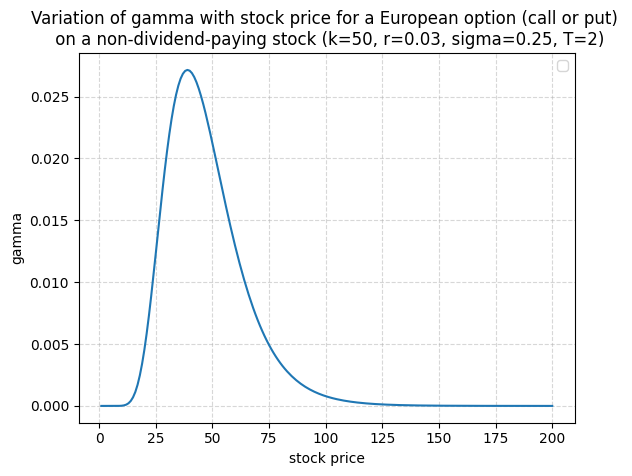

In [23]:
stocks = np.linspace(1,200,200)
k, r, sigma, T = 50, 0.03, 0.25, 2

gammas = gamma(s=stocks, k=k, r=r, sigma=sigma, T=T)

plt.plot(stocks, gammas)
plt.ylabel('gamma')
plt.xlabel('stock price')
plt.title('Variation of gamma with stock price for a European option (call or put) \n on a non-dividend-paying stock (k=50, r=0.03, sigma=0.25, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

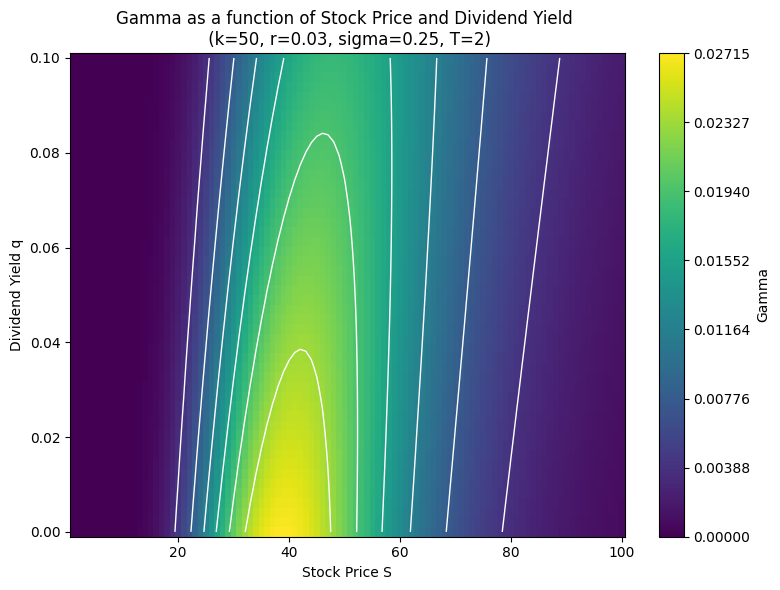

In [24]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

gamma_map = gamma(s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(gamma_map.min(), gamma_map.max(), 8)

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(S, Q, gamma_map, shading='auto', cmap='viridis')
plt.contour(S, Q, gamma_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Gamma', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Gamma as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2)')
plt.tight_layout() 
plt.show()

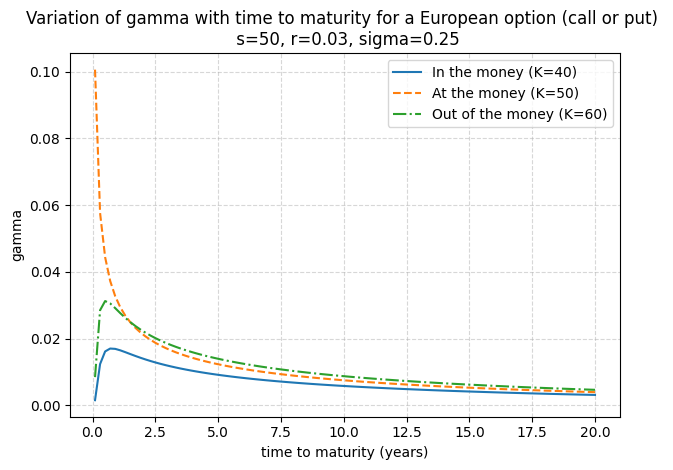

In [25]:
maturities = np.linspace(0.1,20,100)

for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    gammas = gamma(s=50, k=k, r=0.03, sigma=0.25, T=maturities)
    plt.plot(maturities, gammas, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('gamma')
plt.xlabel('time to maturity (years)')
plt.title('Variation of gamma with time to maturity for a European option (call or put) \n s=50, r=0.03, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

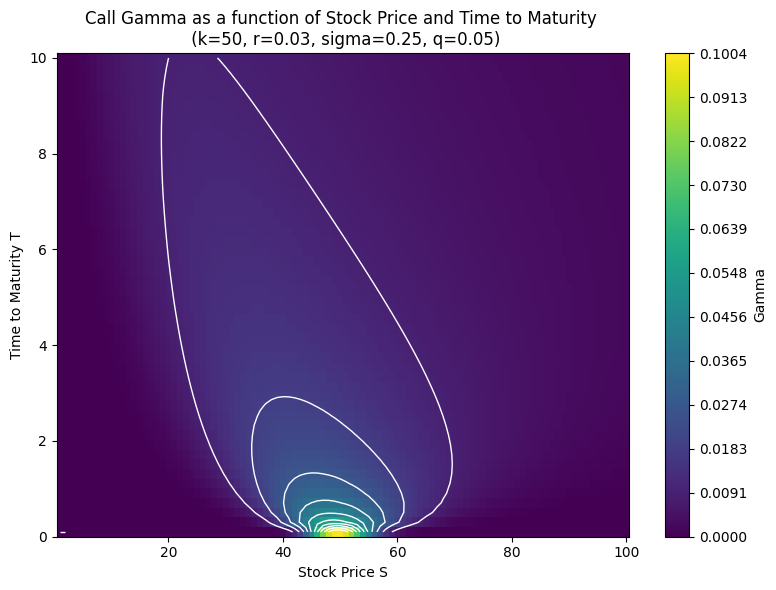

In [26]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

gamma_map = gamma(s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)

levels = np.linspace(gamma_map.min(), gamma_map.max(), 12)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(S, M, gamma_map, shading='auto', cmap='viridis')
plt.contour(S, M, gamma_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Gamma', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Call Gamma as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.tight_layout() 
plt.show()

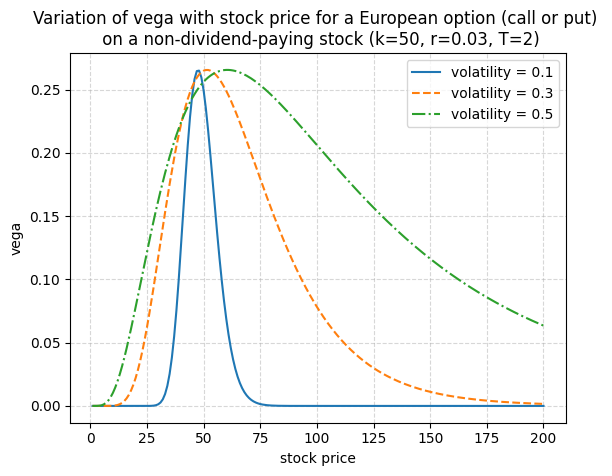

In [13]:
stocks = np.linspace(1,200,200)
k, r, T = 50, 0.03, 2
vega_vec = np.vectorize(vega)

for sigma, linestyle in zip(
    [0.1, 0.3, 0.5],
    ['-','--','-.']
):
    vegas = vega_vec(s=stocks, k=k, r=r, sigma=sigma, T=T)
    plt.plot(stocks, vegas, linestyle=linestyle, label=f'volatility = {sigma}')
plt.ylabel('vega')
plt.xlabel('stock price')
plt.title('Variation of vega with stock price for a European option (call or put) \n on a non-dividend-paying stock (k=50, r=0.03, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

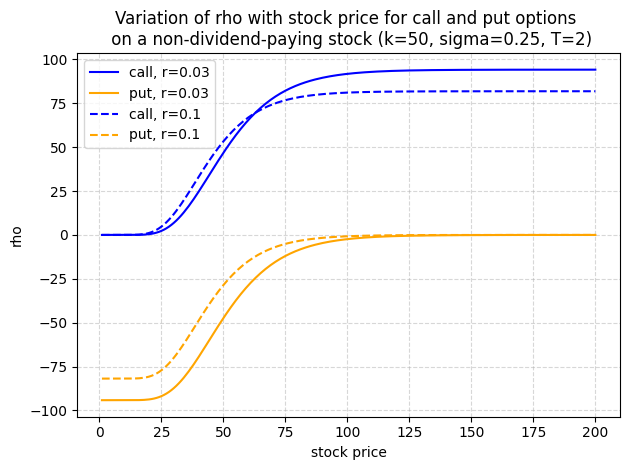

In [14]:
stocks = np.linspace(1,200,200)
k, sigma, T = 50, 0.25, 2
rho_vec = np.vectorize(rho)

for r, linestyle in zip([0.03, 0.10], ['-','--']):
    rhos_call = rho_vec(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
    rhos_put = rho_vec(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

    plt.plot(stocks, rhos_call, linestyle=linestyle, color='blue', label=f'call, r={r}')
    plt.plot(stocks, rhos_put, linestyle=linestyle, color='orange', label=f'put, r={r}')
#plt.axhline(y=theta_gap, color='r', linestyle='--', label='Theoretical theta gap (r*k*exp(-r*T))')
#plt.fill_between(stocks, thetas_call, thetas_put, color='grey', alpha=0.2, label='Theta gap between call and put')
plt.ylabel('rho')
plt.xlabel('stock price')
plt.title('Variation of rho with stock price for call and put options \n on a non-dividend-paying stock (k=50, sigma=0.25, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()